# Chapter 9: Text Processing and Multiclass Classification

## 📋 Summary

Text is one of the most abundant forms of unstructured data. Before applying ML, text must be converted to numerical representations. This chapter covers the full NLP pipeline: text cleaning and preprocessing, vectorization techniques (Bag of Words, TF-IDF, n-grams), text classification models, and multiclass classification strategies.

---

## 🧠 Theoretical Explanation

### Text Vectorization

**CountVectorizer (Bag of Words)**: Creates a matrix where each row is a document and each column is a word. Cell values are raw word counts.

**TF-IDF (Term Frequency-Inverse Document Frequency)**: Weights words by importance:
- `TF(t,d) = count(t in d) / total words in d`
- `IDF(t) = log(N / df(t))` where N = total docs, df(t) = docs containing t
- Words common across all documents (like "the") get low IDF. Rare but meaningful words get high IDF.

**N-grams**: Capture sequences of N words. Bigrams capture phrases like "not good" vs just "good" and "not".

### Text Preprocessing
Typical steps: lowercasing, removing punctuation, removing stop words, stemming/lemmatization, tokenization.

### Multiclass Strategies
- **OvR**: One binary classifier per class
- **Multinomial models**: Directly support multiple classes (Naive Bayes, SGD)


In [1]:
import re
import numpy as np
import pandas as pd

# Sample texts
corpus = [
    "The quick brown fox jumps over the lazy dog!",
    "Machine learning is amazing and fun.",
    "scikit-learn makes ML easy for Python developers.",
    "Natural language processing is a core ML task.",
    "Text classification requires feature extraction."
]

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    return text.strip()

cleaned = [preprocess_text(t) for t in corpus]
for original, clean in zip(corpus, cleaned):
    print(f'Original: {original}')
    print(f'Cleaned:  {clean}\n')


Original: The quick brown fox jumps over the lazy dog!
Cleaned:  the quick brown fox jumps over the lazy dog

Original: Machine learning is amazing and fun.
Cleaned:  machine learning is amazing and fun

Original: scikit-learn makes ML easy for Python developers.
Cleaned:  scikitlearn makes ml easy for python developers

Original: Natural language processing is a core ML task.
Cleaned:  natural language processing is a core ml task

Original: Text classification requires feature extraction.
Cleaned:  text classification requires feature extraction



## 9.2 CountVectorizer (Bag of Words)

In [2]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

vectorizer = CountVectorizer(stop_words='english')
X_counts = vectorizer.fit_transform(cleaned)

print(f'Vocabulary size: {len(vectorizer.vocabulary_)}')
print(f'Matrix shape: {X_counts.shape}')

bow_df = pd.DataFrame(X_counts.toarray(), columns=vectorizer.get_feature_names_out())
print(bow_df)


Vocabulary size: 26
Matrix shape: (5, 26)
   amazing  brown  classification  core  developers  dog  easy  extraction  \
0        0      1               0     0           0    1     0           0   
1        1      0               0     0           0    0     0           0   
2        0      0               0     0           1    0     1           0   
3        0      0               0     1           0    0     0           0   
4        0      0               1     0           0    0     0           1   

   feature  fox  ...  makes  ml  natural  processing  python  quick  requires  \
0        0    1  ...      0   0        0           0       0      1         0   
1        0    0  ...      0   0        0           0       0      0         0   
2        0    0  ...      1   1        0           0       1      0         0   
3        0    0  ...      0   1        1           1       0      0         0   
4        1    0  ...      0   0        0           0       0      0         1   

  

## 9.3 TF-IDF Vectorizer

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')
X_tfidf = tfidf.fit_transform(cleaned)

tfidf_df = pd.DataFrame(X_tfidf.toarray().round(4), columns=tfidf.get_feature_names_out())
print('TF-IDF Matrix:')
print(tfidf_df)


TF-IDF Matrix:
   amazing   brown  classification    core  developers     dog    easy  \
0      0.0  0.4082          0.0000  0.0000      0.0000  0.4082  0.0000   
1      0.5  0.0000          0.0000  0.0000      0.0000  0.0000  0.0000   
2      0.0  0.0000          0.0000  0.0000      0.4207  0.0000  0.4207   
3      0.0  0.0000          0.0000  0.4207      0.0000  0.0000  0.0000   
4      0.0  0.0000          0.4472  0.0000      0.0000  0.0000  0.0000   

   extraction  feature     fox  ...   makes      ml  natural  processing  \
0      0.0000   0.0000  0.4082  ...  0.0000  0.0000   0.0000      0.0000   
1      0.0000   0.0000  0.0000  ...  0.0000  0.0000   0.0000      0.0000   
2      0.0000   0.0000  0.0000  ...  0.4207  0.3394   0.0000      0.0000   
3      0.0000   0.0000  0.0000  ...  0.0000  0.3394   0.4207      0.4207   
4      0.4472   0.4472  0.0000  ...  0.0000  0.0000   0.0000      0.0000   

   python   quick  requires  scikitlearn    task    text  
0  0.0000  0.4082    0.0

## 9.4 Text Classification Pipeline — Synthetic Multi-Class Dataset

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import numpy as np

# Synthetic multi-class text dataset
categories = ['science', 'politics', 'sports', 'technology']
texts_by_cat = {
    'science':    ["The telescope discovered a new planet",
                   "Scientists found water on Mars surface",
                   "Quantum mechanics experiment reveals new results",
                   "New species found in the deep ocean",
                   "Dark matter study published by researchers",
                   "DNA mutation process explained in new study",
                   "Astronomers detect gravitational waves",
                   "Biology lab discovers enzyme mechanism",
                   "New vaccine developed against viral infection",
                   "Geological survey maps tectonic plates"],
    'politics':   ["The senator introduced a new healthcare bill",
                   "Election results show major voter shifts",
                   "President signs executive order on immigration",
                   "Parliament approves new national budget",
                   "Diplomats negotiate international trade deal",
                   "Mayor announces urban development policies",
                   "Congress debates infrastructure spending",
                   "Government proposes tax reform legislation",
                   "Foreign minister meets with ambassador",
                   "Political party releases new campaign platform"],
    'sports':     ["Team wins championship in overtime thriller",
                   "Athlete breaks 100 meter sprint record",
                   "Football season ends with record viewership",
                   "Basketball player signs major contract",
                   "Tennis tournament postponed due to weather",
                   "Soccer team qualifies for world cup finals",
                   "Marathon runner sets new personal record",
                   "Olympic swimmer wins gold medal event",
                   "Baseball pitcher throws perfect game",
                   "Rugby team defeats rivals in international match"],
    'technology': ["Startup launches new AI software platform",
                   "Engineers develop faster microchip processor",
                   "Security update patches critical vulnerability",
                   "New programming language released by company",
                   "Robot performs complex assembly tasks",
                   "Cloud platform scales to millions of users",
                   "Cybersecurity team discovers ransomware attack",
                   "Smartphone battery life doubled with new tech",
                   "Open source framework gains developer support",
                   "Data center uses renewable energy sources"]
}

all_texts, all_labels = [], []
for idx, (cat, docs) in enumerate(texts_by_cat.items()):
    all_texts.extend(docs * 4)
    all_labels.extend([idx] * len(docs) * 4)

X_train, X_test, y_train, y_test = train_test_split(
    all_texts, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

text_clf = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', ngram_range=(1, 2))),
    ('clf', MultinomialNB())
])
text_clf.fit(X_train, y_train)
y_pred = text_clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=categories))


              precision    recall  f1-score   support

     science       1.00      1.00      1.00         8
    politics       1.00      1.00      1.00         8
      sports       1.00      1.00      1.00         8
  technology       1.00      1.00      1.00         8

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32



## 9.5 N-gram Comparison

In [5]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score

for ngram in [(1,1), (1,2), (2,2)]:
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english', ngram_range=ngram)),
        ('clf', SGDClassifier(random_state=42, max_iter=200))
    ])
    score = cross_val_score(pipe, all_texts, all_labels, cv=4).mean()
    print(f'N-gram range {ngram}: {score:.4f}')


N-gram range (1, 1): 1.0000
N-gram range (1, 2): 1.0000
N-gram range (2, 2): 1.0000


## 9.6 Confusion Matrix

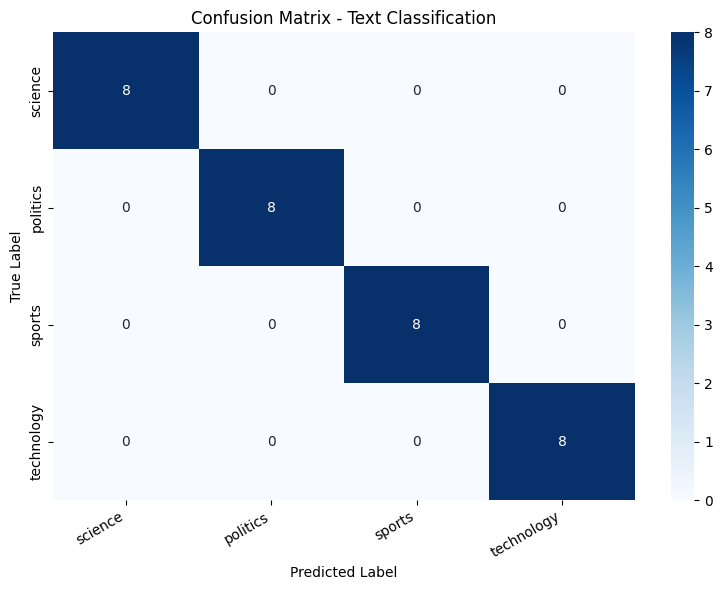

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=categories, yticklabels=categories, cmap='Blues')
plt.title('Confusion Matrix - Text Classification')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 🔑 Key Takeaways

- **CountVectorizer** gives raw word counts; **TfidfVectorizer** gives importance-weighted counts.
- TF-IDF is almost always better than raw counts — it down-weights common words automatically.
- **N-grams** capture word sequences and often improve accuracy for phrase-sensitive tasks.
- **Multinomial Naive Bayes** is a fast, strong baseline for text classification.
- **SGDClassifier** with TF-IDF scales well to large text corpora.
- Always use a `Pipeline` to ensure the vectorizer is fit only on training data.
